In [1]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv to zomato.csv


In [2]:
# =============================================
# ZOMATO RESTAURANT ANALYSIS
# Dataset: Zomato Restaurants Data from Kaggle
# Tools: Python, Pandas, Matplotlib, Seaborn
# =============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/zomato.csv", encoding="latin1")

print("Original Shape:", df.shape)

# =============================================
# DATA CLEANING
# =============================================

# Check for missing values
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove rows with missing Cuisines (only 9 rows affected)
df = df.dropna(subset=["Cuisines"])

# Confirm cleaning worked
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nFinal Clean Shape:", df.shape)

Original Shape: (9551, 21)

Missing Values Before Cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Duplicate Rows: 0

Missing Values After Cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking 

Most Saturated Cities (Highest Competition):
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64

Sweet Spot Cities (10-50 restaurants, Lower Competition):
City
Sandton         11
ÛÁstanbul       14
Jakarta         16
Albany          17
Hyderabad       18
                ..
Bhubaneshwar    21
Guwahati        21
Ahmedabad       21
Amritsar        21
Ghaziabad       25
Name: count, Length: 78, dtype: int64


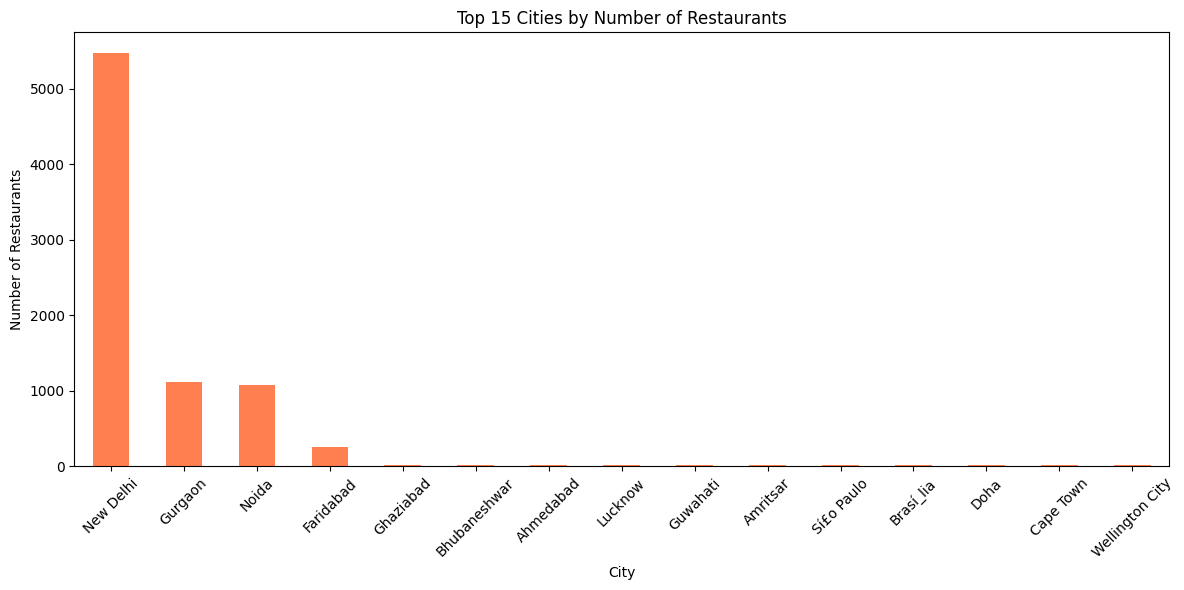

In [3]:
# =============================================
# QUESTION 1: WHICH CITIES HAVE LEAST COMPETITION?
# =============================================

city_counts = df["City"].value_counts()

print("Most Saturated Cities (Highest Competition):")
print(city_counts.head(10))

print("\nSweet Spot Cities (10-50 restaurants, Lower Competition):")
sweet_spot = city_counts[(city_counts >= 10) & (city_counts <= 50)]
print(sweet_spot.sort_values())

# Chart
plt.figure(figsize=(12,6))
city_counts.head(15).plot(kind="bar", color="coral")
plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 15 Most Popular Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Name: count, dtype: int64


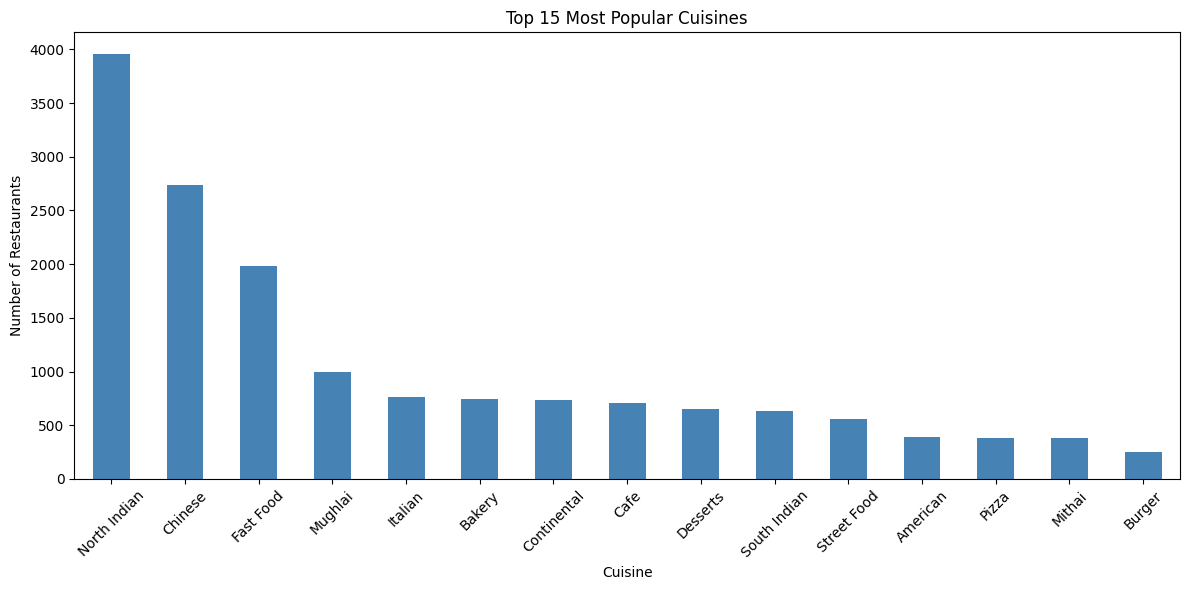

In [4]:
# =============================================
# QUESTION 2: WHICH CUISINE IS MOST POPULAR?
# =============================================

all_cuisines = df["Cuisines"].str.split(", ").explode()
cuisine_counts = all_cuisines.value_counts().head(15)

print("Top 15 Most Popular Cuisines:")
print(cuisine_counts)

# Chart
plt.figure(figsize=(12,6))
cuisine_counts.plot(kind="bar", color="steelblue")
plt.title("Top 15 Most Popular Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Rating by Price Range:
Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64


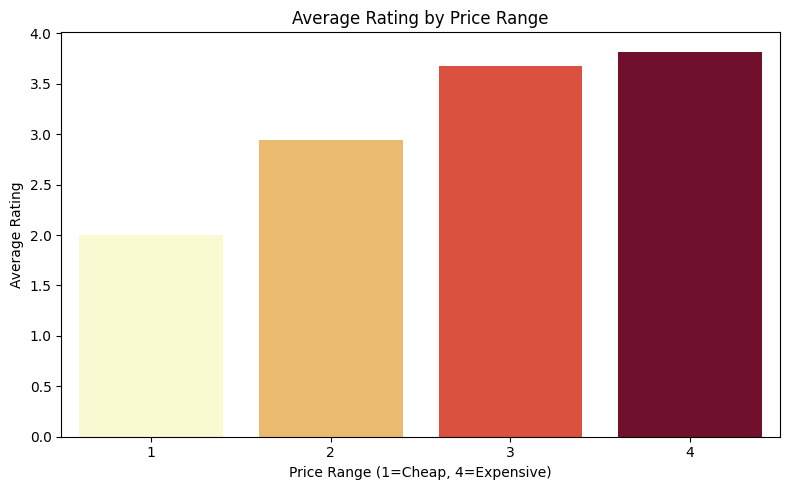

In [5]:
# =============================================
# QUESTION 3: WHAT PRICE RANGE GETS HIGHEST RATINGS?
# =============================================

price_rating = df.groupby("Price range")["Aggregate rating"].mean().round(2)
print("Average Rating by Price Range:")
print(price_rating)

# Chart
plt.figure(figsize=(8,5))
sns.barplot(x=price_rating.index, y=price_rating.values, hue=price_rating.index, palette="YlOrRd", legend=False)
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range (1=Cheap, 4=Expensive)")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

Average Rating by Online Delivery:
Has Online delivery
No     2.46
Yes    3.25
Name: Aggregate rating, dtype: float64


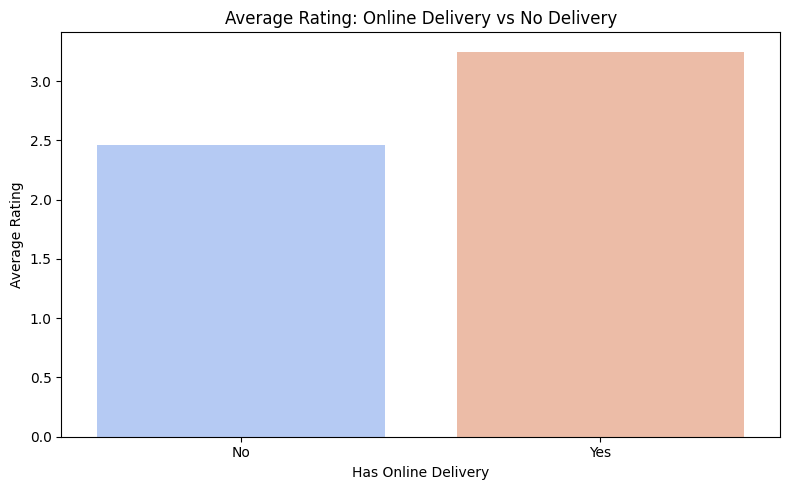

In [6]:
# =============================================
# QUESTION 4: DOES ONLINE DELIVERY AFFECT RATINGS?
# =============================================

delivery_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean().round(2)
print("Average Rating by Online Delivery:")
print(delivery_rating)

# Chart
plt.figure(figsize=(8,5))
sns.barplot(x=delivery_rating.index, y=delivery_rating.values, hue=delivery_rating.index, palette="coolwarm", legend=False)
plt.title("Average Rating: Online Delivery vs No Delivery")
plt.xlabel("Has Online Delivery")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

Top 10 Most Expensive Indian Cities:
City
Panchkula    2000.00
Hyderabad    1361.11
Pune         1337.50
Jaipur       1310.00
Kolkata      1272.50
Bangalore    1232.50
Goa          1175.00
Ludhiana     1160.00
Chennai      1085.00
Mumbai       1072.50
Name: Average Cost for two, dtype: float64


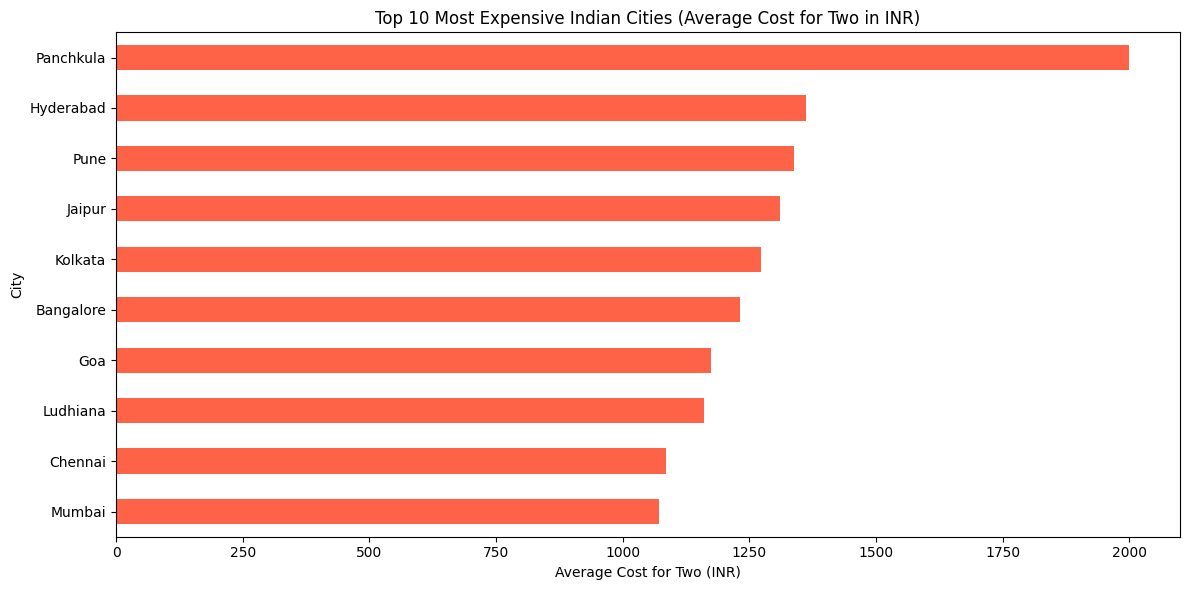

In [7]:
# =============================================
# QUESTION 5: WHICH CITY IS MOST EXPENSIVE TO EAT IN?
# =============================================

# Filter Indian restaurants only (Country Code 1 = India)
# Note: Filtering to India only since most data is from India
# and currencies vary across other countries
india_df = df[df["Country Code"] == 1]

india_cost = india_df.groupby("City")["Average Cost for two"].mean().round(2)
india_cost_top10 = india_cost.sort_values(ascending=False).head(10)

print("Top 10 Most Expensive Indian Cities:")
print(india_cost_top10)

# Chart
plt.figure(figsize=(12,6))
india_cost_top10.sort_values().plot(kind="barh", color="tomato")
plt.title("Top 10 Most Expensive Indian Cities (Average Cost for Two in INR)")
plt.xlabel("Average Cost for Two (INR)")
plt.tight_layout()
plt.show()

Top 10 Most Voted Restaurants:
                Restaurant Name       City  \
728                        Toit  Bangalore   
735                    Truffles  Bangalore   
3994           Hauz Khas Social  New Delhi   
2412                  Peter Cat    Kolkata   
739   AB's - Absolute Barbecues  Bangalore   
2414            Barbeque Nation    Kolkata   
743                 Big Brewsky  Bangalore   
2307  AB's - Absolute Barbecues  Hyderabad   
736             The Black Pearl  Bangalore   
2411                      BarBQ    Kolkata   

                                               Cuisines  Aggregate rating  \
728                            Italian, American, Pizza               4.8   
735                              American, Burger, Cafe               4.7   
3994         Continental, American, Asian, North Indian               4.3   
2412                          Continental, North Indian               4.3   
739               European, Mediterranean, North Indian               4.6   


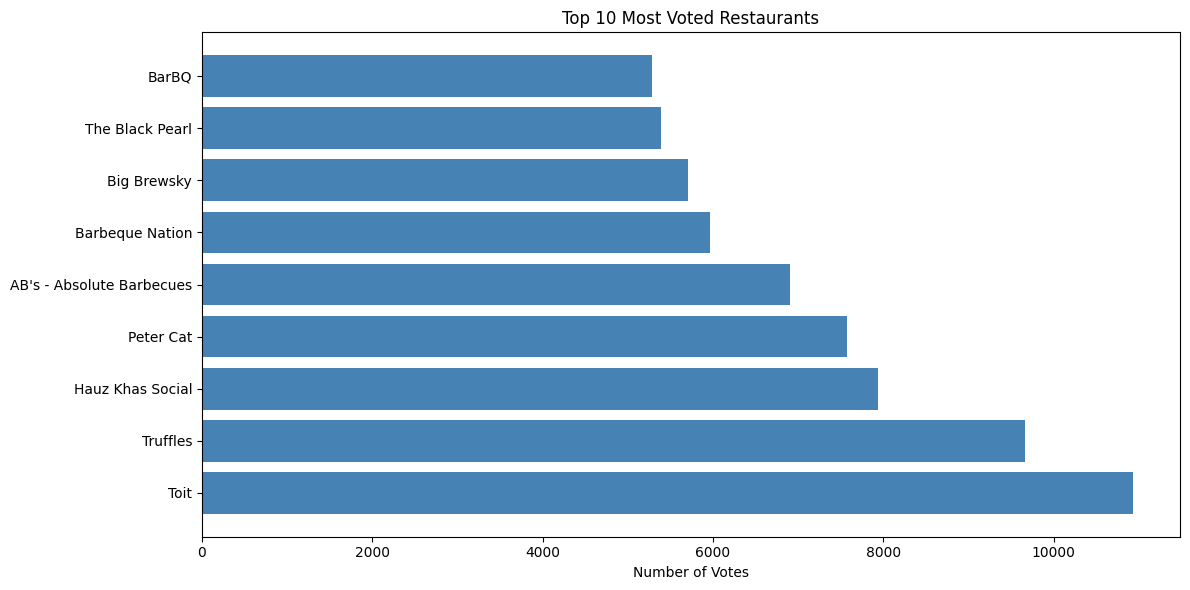

In [8]:
# =============================================
# QUESTION 6: WHICH RESTAURANTS ARE MOST POPULAR (BY VOTES)?
# =============================================

top_voted = df[["Restaurant Name", "City", "Cuisines", "Aggregate rating", "Votes"]].sort_values("Votes", ascending=False).head(10)

print("Top 10 Most Voted Restaurants:")
print(top_voted)

# Chart
plt.figure(figsize=(12,6))
plt.barh(top_voted["Restaurant Name"], top_voted["Votes"], color="steelblue")
plt.title("Top 10 Most Voted Restaurants")
plt.xlabel("Number of Votes")
plt.tight_layout()
plt.show()